Research Project-1 by Ali Suleimenov

Name is Rsearch Project-1: "Optimize of Weather Prediction Using Gaussian Process, Neural ODEs, Physics-Informed Neural Networks, and Inverse Problem Techiques"

Objectives: input a new knowlege a method for solving problem.

Introduction: In Kazakhstan basicaly in world exist method for the forecast weather on the 1,3,6 mounth respectivelty. But what is important in here. Because in nowadays exist only traditional method forecast weather and it is not always give more accurancy results

1. Gaussian process. Model which used in statistic ML and Mathscience, to define a distribution over functions.
Instead of producting a single deterministic output, a GP estimates the entire
distribution of possible functions that fit a given dataset.Gaussian Process is defined as a collection of random variables, any
finite number of which a joint Gaussian distribution. Formally, a GP is com-
pletely specified by it’s mean function m(x) and covariance function (or kernel)
$$k(x, x′):$$

$$ f(x) \sim \mathcal{GP}(m(x),k(x,x'))
 $$

where:
- $$ m(x) = \mathbf{}{E}[f(x)] $$ is the mean function
- $$ k(x,x') = \mathbf{}{E}[f(x) - m(x))(f(x') - m(x'))] $$ is the covariance function

1.1 Algorithm of Gaussian Process

In this section, we describe the basic steps of implementing the Gaussian Process
(GP) algorithm for weather prediction.

1.1.1 Load the dataset

$$ \mathbf{x} = \{x_1, x_2, x_3, x_4, \dots, x_n\} $$


$$ \mathbf{y} = \{y_1, y_2, y_3, x_4, \dots, y_n\} $$

Important moment  X  is all data which we want implies result.  Y  is output data

 1.1.2 We choose a kernel (covariance) function k(x, x′) that encodes assumptions
about the function we wish to learn. A commonly used kernel is the squared
exponential (RBF) kernel:

$$ k(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2l^2}\right) $$

where $\sigma_f^2$ is the signal variance and $l$ is the length scale parameter.

1.1.3 Compute the Covariance Matrix


Using the kernel function, we compute the covariance matrix $K$ for the training inputs:

$$K_{ij} = k(x_i, x_j)$$

We also add noise variance $\sigma_n^2$ to the diagonal:

$$K = K + \sigma_n^2 I$$


1.1.4 Specify the Prior Distribution

Before observing any data, we assume a joint Gaussian prior over the training outputs $\mathbf{y}$ and the test outputs $\mathbf{f}_*$:
$$
\begin{bmatrix}
\mathbf{y} \\
\mathbf{f}_*
\end{bmatrix}
\sim \mathcal{N}\left(
0,
\begin{bmatrix}
K(X, X) + \sigma_n^2 I & K(X, X_*) \\
K(X_*, X) & K(X_*, X_*)
\end{bmatrix}
\right)
$$

1.1.5 Compute the Posterior Distribution

Given the observed data $\mathbf{y}$, the posterior distribution over test outputs $\mathbf{f}_*$ is Gaussian with the following mean and covariance:
$$
\mathbf{E}[\mathbf{f}_*] = K(X_*, X)[K(X, X) + \sigma_n^2 I]^{-1} \mathbf{y}
$$
$$
\text{Cov}[\mathbf{f}_*] = K(X_*, X_*) - K(X_*, X)[K(X, X) + \sigma_n^2 I]^{-1} K(X, X_*)
$$


1.1.6 Make Predictions

We use the posterior mean $\mathbf{E}[\mathbf{f}_*]$ as the prediction, and the posterior covariance provides uncertainty estimates. This allows not only forecasting values but also quantifying confidence in those predictions.

1.2.1 Real World Example

Given data

In [1]:
import pandas as pd

dataset = {
    "Temperature(C)": [-9, -9, -10, -10],
    "Himidity(%)": [91, 91, 90, 91],
    "Wind Shear": [1,1,1,2],
    "Gradient Temperature": [1,2,2,3],
    "mm": [0,0,0,0]
}

df = pd.DataFrame(dataset)

In [2]:
df

,Temperature(C),Himidity(%),Wind Shear,Gradient Temperature,mm
0,-9,91,1,1,0
1,-9,91,1,2,0
2,-10,90,1,2,0
3,-10,91,2,3,0


Comment: We are working with Psycical data. Some times may be mistakes. 

Step1:

In [3]:
# Standar

KeyError: 'CAPE(J/Kg)'

In [20]:
X = np.array([[22,50],
              [23,41],
              [33,25],
              [31,31]])
Y = np.array([100,0,200,0])
X_new=[28,65]

Step2:

In [28]:
import numpy as np

# === Исходные данные ===
X = np.array([[22, 50],
              [23, 41],
              [33, 25],
              [31, 31]])
Y = np.array([100, 0, 200, 0])

# === Гиперпараметры ===
l_temp = 10      # длина масштаба по температуре
l_him = 10       # длина масштаба по влажности
sigma_f = 1   # амплитуда ядра
std_n=0.01
# === Определение ядра ===
def rbf_kernel(x1, x2, l1, l2):
    """Гауссовское (RBF) ядро для двумерного входа [T, H]."""
    return sigma_f**2 * np.exp(
        -((x1[0] - x2[0])**2) / (2 * l1**2)
        -((x1[1] - x2[1])**2) / (2 * l2**2)
    )



Step 3:

In [29]:
# === Формирование ковариационной матрицы ===
n = len(X)
K = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        K[i, j] = rbf_kernel(X[i], X[j], l_temp, l_him)

# === Проверка ===
print("Ковариационная матрица K:\n", K)
# Добавим шум на диагональ
K += std_n**2 * np.eye(n)
print(K)

Ковариационная матрица K:
 [[1.         0.66365025 0.02399284 0.10970065]
 [0.66365025 1.         0.16863815 0.44043165]
 [0.02399284 0.16863815 1.         0.81873075]
 [0.10970065 0.44043165 0.81873075 1.        ]]
[[1.0001     0.66365025 0.02399284 0.10970065]
 [0.66365025 1.0001     0.16863815 0.44043165]
 [0.02399284 0.16863815 1.0001     0.81873075]
 [0.10970065 0.44043165 0.81873075 1.0001    ]]


In [30]:
K_vec = np.array([rbf_kernel(X[i], X_new, l_temp, l_him) for i in range(n)])
print(K_vec)

[0.27117254 0.04953875 0.00029604 0.0029528 ]


In [31]:
inverse=np.linalg.inv(K)
print(inverse)

[[ 2.01832934 -1.67705982 -0.57308175  0.98631921]
 [-1.67705982  2.83343948  1.31401129 -2.13956938]
 [-0.57308175  1.31401129  3.68191794 -3.53001117]
 [ 0.98631921 -2.13956938 -3.53001117  4.72379055]]


Step4: Step5:

In [32]:
pred_mean=K_vec @ inverse @ Y
var_pred = rbf_kernel(X_new, X_new, l_temp, l_him) - K_vec @ inverse @ K_vec
print("Prediction CAPE:", pred_mean)
print("Standard deviation:", np.sqrt(var_pred))

Prediction CAPE: 26.769284301036933
Standard deviation: 0.942736359566945


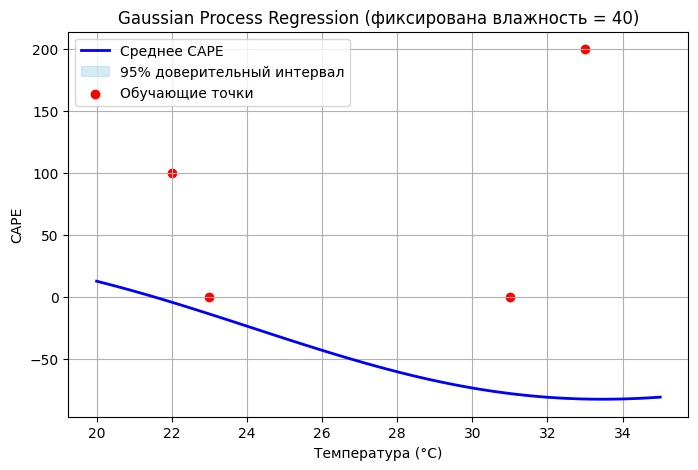

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# === Исходные данные ===
X = np.array([[22, 50],
              [23, 41],
              [33, 25],
              [31, 31]])
Y = np.array([100, 0, 200, 0])

l_temp = 10
l_him = 10
sigma_f = 0.01
sigma_n = 1e-6

def rbf_kernel(x1, x2, l1, l2):
    return sigma_f**2 * np.exp(
        -((x1[0] - x2[0])**2) / (2 * l1**2)
        -((x1[1] - x2[1])**2) / (2 * l2**2)
    )

# === Ковариационная матрица ===
n = len(X)
K = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        K[i, j] = rbf_kernel(X[i], X[j], l_temp, l_him)
K += sigma_n * np.eye(n)  # для численной стабильности

# === Прогноз на сетке температур (фиксируем влажность = 40) ===
T_star = np.linspace(20, 35, 100)
H_star = np.full_like(T_star, 40)
X_star = np.vstack((T_star, H_star)).T

# Ковариации
def kernel_matrix(X1, X2):
    m, n = len(X1), len(X2)
    Kmat = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            Kmat[i, j] = rbf_kernel(X1[i], X2[j], l_temp, l_him)
    return Kmat

K_s = kernel_matrix(X, X_star)
K_ss = kernel_matrix(X_star, X_star)
K_inv = np.linalg.inv(K)

# === Среднее и дисперсия ===
mu_s = K_s.T @ K_inv @ Y
sigma_s = np.diag(K_ss - K_s.T @ K_inv @ K_s)

# === Визуализация ===
plt.figure(figsize=(8,5))
plt.plot(T_star, mu_s, 'b', lw=2, label='Среднее CAPE')
plt.fill_between(T_star, 
                 mu_s - 2*np.sqrt(sigma_s),
                 mu_s + 2*np.sqrt(sigma_s),
                 color='lightblue', alpha=0.5, label='95% доверительный интервал')
plt.scatter(X[:,0], Y, c='r', label='Обучающие точки')
plt.xlabel('Температура (°C)')
plt.ylabel('CAPE')
plt.title('Gaussian Process Regression (фиксирована влажность = 40)')
plt.legend()
plt.grid(True)
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_features(t):
    # Твои функции
    T = 20 * (1/np.sqrt(2*np.pi) * np.exp(-t**2)) + np.cos(3*t)
    H = 70 + np.exp(-t**2)
    TGrad = 25 * np.cos(2*t) + 25 * np.sin(2*t)
    WS = 10 * np.cos(t) + 10 * np.sin(t)
    return np.array([T, H, TGrad, WS]).T

# Временная сетка для прогноза
t_grid = np.linspace(-3, 3, 200)
X_grid = get_features(t_grid)

# Точки "замеров" в экспедиции (например, 3 замера)
t_obs = np.array([-2.0, 0.0, 1.5])
y_obs = np.array([5.0, 12.0, 7.0]) # Задержка в минутах
X_obs = get_features(t_obs)

In [2]:
def rbf_kernel(x1, x2, l=1.0):
    # Евклидово расстояние между векторами признаков
    sq_dist = np.sum(x1**2, 1).reshape(-1, 1) + np.sum(x2**2, 1) - 2 * np.dot(x1, x2.T)
    return np.exp(-0.5 * sq_dist / l**2)

sigma_n = 0.1  # Шум измерений
l_param = 2.0  # Длина связи (smoothness)

# Матрицы ковариации
K = rbf_kernel(X_obs, X_obs) + sigma_n**2 * np.eye(len(X_obs))
K_s = rbf_kernel(X_obs, X_grid)
K_ss = rbf_kernel(X_grid, X_grid)

# Твоя формула: Mean = K_s.T @ inv(K) @ y
mu_s = K_s.T @ np.linalg.inv(K) @ y_obs

# Твоя формула: Cov = K_ss - K_s.T @ inv(K) @ K_s
cov_s = K_ss - K_s.T @ np.linalg.inv(K) @ K_s
std_s = np.sqrt(np.diag(cov_s))

In [5]:

print(cov_s)

[[1.00000000e+00 6.05274438e-01 1.67760628e-01 ... 2.14438342e-72
  1.36816477e-57 7.70663817e-45]
 [6.05274438e-01 1.00000000e+00 6.74387846e-01 ... 1.69330948e-80
  7.82397271e-65 3.02128683e-51]
 [1.67760628e-01 6.74387846e-01 1.00000000e+00 ... 5.04128122e-88
  1.33895663e-71 2.83190068e-57]
 ...
 [2.14438342e-72 1.69330948e-80 5.04128122e-88 ... 1.00000000e+00
  1.39280727e-01 4.68504135e-04]
 [1.36816477e-57 7.82397271e-65 1.33895663e-71 ... 1.39280727e-01
  1.00000000e+00 1.55283807e-01]
 [7.70663817e-45 3.02128683e-51 2.83190068e-57 ... 4.68504135e-04
  1.55283807e-01 1.00000000e+00]]
